In [2]:
# PHASE 1: RISK ENGINE

In [3]:
# Calculating the log returns of the stocks within the portfolio

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

In [5]:
n = int(input("Enter the number of stocks in your portfolio: "))
tickers = []
weight = []

# Logging the stocks within the portfolio of the user; and the weightage each of them carries in the portfolio
# (I can ig optimize this by storing the stock and its weight in a pair)

for i in range(n):
    stock = input("Enter the stock in your portfolio: ")
    tickers.append(stock)
    wt = int(input("Enter its weightage within your portfolio: "))
    weight.append(wt)

print(tickers, weight)

['AAPL', 'NKE', 'LULU'] [70, 15, 15]


In [6]:
data = pd.DataFrame()

# Used a for loop to fetch all the sources,
# and made it (the comment and the code)
# multi-line to avoid getting flagged by Ruff

for ticker in tickers:
    data[ticker] = yf.download(
        ticker,
        start="2015-01-01",
        auto_adjust=False,
    )["Adj Close"]

data.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,AAPL,NKE,LULU
Date,,,
2015-01-02,24.171757,40.316387,55.340000
2015-01-05,23.490797,39.667286,55.959999
2015-01-06,23.493013,39.433952,55.570000
2015-01-07,23.822435,40.248505,57.650002
2015-01-08,24.737745,41.177628,59.070000


In [7]:
log_returns_of_portfolio = pd.DataFrame()
column_list = data.columns.tolist()

# Calculated the Log Return
# Not simple return coz,
# simple return = Single portfolio comparison
# log return = multiple portfolio comparsion

for ticker in column_list:
    log_returns_of_portfolio[ticker] = np.log(data[ticker] / data[ticker].shift(1))

log_returns_of_portfolio.head()

,AAPL,NKE,LULU
Date,,,
2015-01-02,NaN,NaN,NaN
2015-01-05,-0.028576,-0.016231,0.011141
2015-01-06,0.000094,-0.005900,-0.006994
2015-01-07,0.013925,0.020446,0.036747
2015-01-08,0.037702,0.022822,0.024333


In [8]:
# Annualization of the data

In [9]:
annualized_return = pd.DataFrame(index=["Annualized Return"])

for ticker in column_list:
    mean_daily_log_return = log_returns_of_portfolio[ticker].mean()

    # recently learnt should prefer 252 over 250
    # for number of trading days within a year
    annualized_return[ticker] = np.exp(mean_daily_log_return * 252) - 1

print(annualized_return)

                       AAPL       NKE      LULU
Annualized Return  0.250991 -0.014753  0.046669


In [10]:
# calculating standard deviation, variance, covariance and correlation

In [11]:
# Just now learnt the concept of "VECTORIZATION".
# Thanks to vectorization, we do not require to loop through
# all the stocks in the portfolio and calculate the variance individually,
# but rather can do the task within one single statement

# THEREFORE,

annualized_variance_of_stocks = log_returns_of_portfolio.var() * 252
annualized_standard_deviation_of_stocks = log_returns_of_portfolio.std() * np.sqrt(252)
annualized_covariance_of_stocks = log_returns_of_portfolio.cov() * 252
# Correlation is a unitless ratio and thus doesn't require to be multiplied with 250
annualized_correlation_of_stocks = log_returns_of_portfolio.corr()

print(f"Annualized std deviation: {annualized_standard_deviation_of_stocks}\n")
print(f"Annualized variance: {annualized_variance_of_stocks}\n")
print(f"Annualized covariance: {annualized_covariance_of_stocks}\n")
print(f"Annualized correlation: {annualized_correlation_of_stocks}\n")

Annualized std deviation: AAPL    0.286868
NKE     0.314604
LULU    0.410832
dtype: float64

Annualized variance: AAPL    0.082293
NKE     0.098976
LULU    0.168783
dtype: float64

Annualized covariance:           AAPL       NKE      LULU
AAPL  0.082293  0.038546  0.042322
NKE   0.038546  0.098976  0.061498
LULU  0.042322  0.061498  0.168783

Annualized correlation:           AAPL       NKE      LULU
AAPL  1.000000  0.427103  0.359102
NKE   0.427103  1.000000  0.475807
LULU  0.359102  0.475807  1.000000



In [12]:
# variance of the portfolio

In [13]:
# variance of a portfoliio, i.e.,
# ((omega1 * sigma1) + (omega2 * sigma2))^2
# =   (omega1^2 * sigma1^2) +
#     (omega2^2 * sigma2^2) +
#     (2 * omega1 * omega2 * sigma1 * sigma2)

# WHERE, omega1 = weightage of stock1 in the portfolio
#        omega2 = weightage of stock2 in the portfolio
#        sigma1 = standard deviation of stock1
#        sigma2 = standard deviation of stock

# BUT, in this scenario, we have the annual standard deviation collectively
# and thus, we can apply the formula:

# Portfolio variance = omega^T * Sigma(Σ) * omega

# WHERE,  omega = vector of weights
#         omega^T = Transposed vector of those weights
#         Sigma (Σ) = Covariance matrix (here, annualized_covariance_of_stocks)

In [14]:
weights_array = np.array(weight) / 100  # divided by 100 to get the decimal values
variance_of_portfolio = np.dot(weights_array.T, np.dot(annualized_covariance_of_stocks, weights_array))
print(f"Variance of the portfolio is: {variance_of_portfolio}")

Variance of the portfolio is: 0.06609800179748718


In [15]:
# Calculating the portfolio return

# Portfolio return = omega1 * R1 + omega2 * R2 + .....

# OR

# Portfolio return = omega^T dot-product R

# WHERE,  omega1 = weight of stock1,
#         omega2 = weight of stock2, ...
#         omega = weights vector
#         omega^T = Transposed vector of weights vector
#         R1 = return of stock1
#         R2 = return of stock2, ...
#         R = returns vector

In [16]:
individual_returns = annualized_return.iloc[0]
portfolio_return = np.dot(weights_array.T, individual_returns)
print(f"Annual portfolio return: {portfolio_return}")

Annual portfolio return: 0.18048101141145792


In [17]:
# Sharpe Ratio

# Sharpe ratio = (risk-free rate - excess return of stock "i") / standard deviation of stock "i"

# Other way to calculate Sharpe Ratio is:
#     Sharpe Ratio = (portfolio return - risk-free rate) / portfolio  volatility
#
# (portfolio volatility = sqrt of the variance of the portfolio)

In [18]:
us_treasury_yield = yf.download("^TNX", period="5d", auto_adjust=False)["Adj Close"]
# Cause we take risk free rate as the current yield on a 10 year US Treasury bond

risk_free_rate = float(us_treasury_yield.iloc[-1].iloc[0]) / 100
print("Current risk-free rate: ", risk_free_rate)

[*********************100%***********************]  1 of 1 completed

Current risk-free rate:  0.05276999950408936


In [19]:
sharpe_ratio = (portfolio_return - risk_free_rate) / np.sqrt(variance_of_portfolio)
print("Sharpe ratio of the portfolio is: ", sharpe_ratio)

Sharpe ratio of the portfolio is:  0.4967457735745133


In [20]:
# PHASE 2: PORTFOLIO OPTIMIZATION THEORY

In [21]:
# Markowitz Portfolio Optimization Theory
# Also calculating the variance and sharpe on each simulation

In [22]:
portfolio_returns = []
portfolio_volatilites = []

max_sharpe = -np.inf
max_sharpe_weights = None

min_variance = np.inf
min_variance_weights = None

for x in range(10000):
    # Calculating the random weights to uuse in the markowitz portfolio optimization theory
    new_weights = np.random.random(n)
    new_weights /= np.sum(new_weights)

    # Calculating and updating the minimum variance during the 10000 simulations
    variance_of_simulation = np.dot(new_weights.T, np.dot(annualized_covariance_of_stocks, new_weights))
    if variance_of_simulation < min_variance:
        min_variance = min(min_variance, variance_of_simulation)
        min_variance_weights = new_weights.copy()

    # Calculating and adding the portfolio returns and volatilities across the 10000 simulations
    portfolio_returns.append(np.sum(new_weights * log_returns_of_portfolio.mean()) * 252)
    portfolio_volatilites.append(np.sqrt(variance_of_simulation))

    # Calculating the sharpe for the simulations and updating the max sharpe
    sharpe_of_simulation = (portfolio_returns[x] - risk_free_rate) / portfolio_volatilites[x]
    if max_sharpe < sharpe_of_simulation:
        max_sharpe = max(max_sharpe, sharpe_of_simulation)
        max_sharpe_weights = new_weights.copy()

portfolio_returns = np.array(portfolio_returns)
portfolio_volatilites = np.array(portfolio_volatilites)

print("Expected portfolio returns: ", portfolio_returns)
print("Expected portfolio volatilies: ", portfolio_volatilites)
print("Max Sharpe: ", max_sharpe)
print("Minimum variance: ", min_variance)

Expected portfolio returns:  [0.09936633 0.14723292 0.04704068 ... 0.04555299 0.11448283 0.09023572]
Expected portfolio volatilies:  [0.26860951 0.26124469 0.26877077 ... 0.32770312 0.29171093 0.26514318]
Max Sharpe:  0.5944549031063171
Minimum variance:  0.06249432919197312


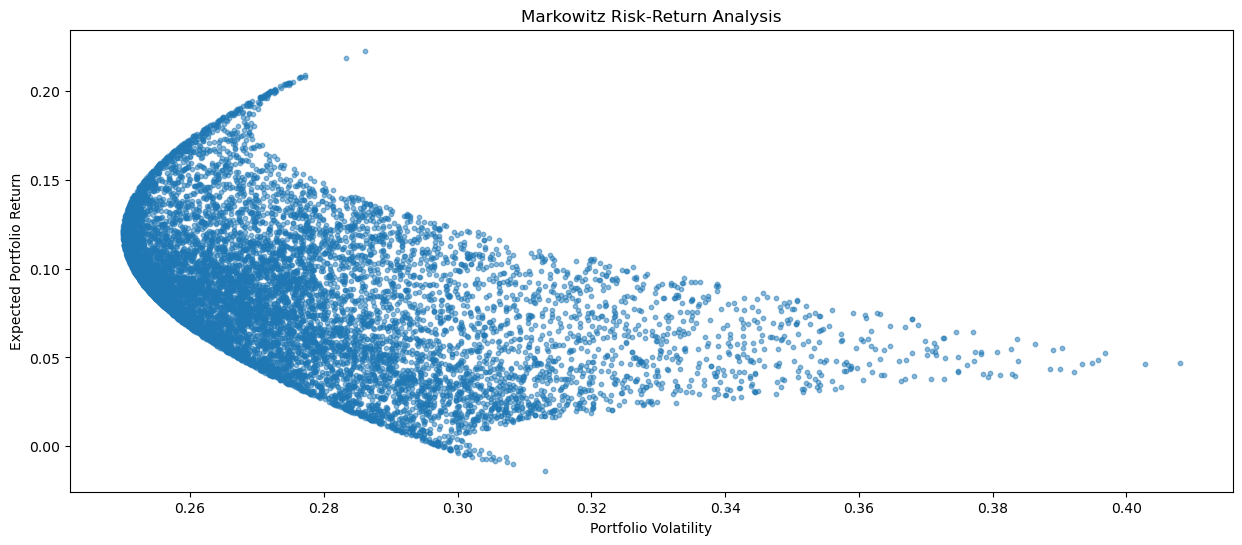

In [23]:
# Calculating the efficient frontier
plt.figure(figsize=(15, 6))
plt.scatter(portfolio_volatilites, portfolio_returns, s=10, alpha=0.5)

plt.xlabel("Portfolio Volatility")
plt.ylabel("Expected Portfolio Return")
plt.title("Markowitz Risk-Return Analysis")

plt.show()

In [24]:
sorted_indices = np.argsort(portfolio_volatilites)

sorted_volatilities = portfolio_volatilites[sorted_indices]

sorted_returns = portfolio_returns[sorted_indices]

max_return_so_far = np.maximum.accumulate(sorted_returns)

efficient_mask = sorted_returns >= max_return_so_far

efficient_volatilities = sorted_volatilities[efficient_mask]

efficient_returns = sorted_returns[efficient_mask]

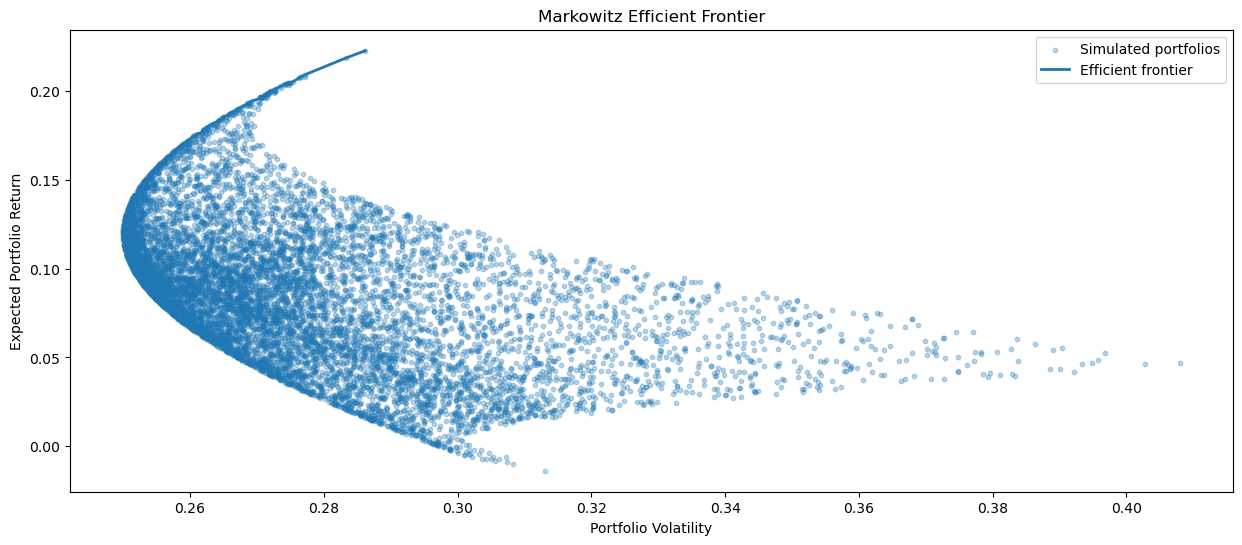

In [25]:
plt.figure(figsize=(15, 6))

# All simulated portfolios
plt.scatter(portfolio_volatilites, portfolio_returns, s=10, alpha=0.3, label="Simulated portfolios")

# Efficient frontier
plt.plot(efficient_volatilities, efficient_returns, linewidth=2, label="Efficient frontier")

plt.xlabel("Portfolio Volatility")
plt.ylabel("Expected Portfolio Return")
plt.title("Markowitz Efficient Frontier")
plt.legend()

plt.show()

In [ ]:
# CAPM

# beta = covariance with market / (variance of the market) ^ 2


In [40]:
# Using the S&P 500 as the market benchmark

market_data = yf.download(
    "^GSPC",
    start="2015-01-01",
    auto_adjust=False,
)["Adj Close"]

market_data = market_data.squeeze()

market_returns = np.log(
    market_data / market_data.shift(1)
).dropna()

market_returns.name = "MARKET"

market_returns.head()

[*********************100%***********************]  1 of 1 completed


Date
2015-01-05   -0.018447
2015-01-06   -0.008933
2015-01-07    0.011563
2015-01-08    0.017730
2015-01-09   -0.008439
Name: MARKET, dtype: float64

In [41]:
# Calculate covariance of each stock with the market

returns_with_market = pd.concat(
    [
        log_returns_of_portfolio,
        market_returns,
    ],
    axis=1,
).dropna()

covariance_matrix_with_market = returns_with_market.cov()

covariance_with_market = (
    covariance_matrix_with_market["MARKET"]
    .drop("MARKET")
)

market_variance = market_returns.var()

beta = covariance_with_market / market_variance

print("Covariance with market:")
print(covariance_with_market)

print("\nMarket variance:")
print(market_variance)

print("\nBeta:")
print(beta)

Covariance with market:
AAPL    0.000147
NKE     0.000125
LULU    0.000140
Name: MARKET, dtype: float64

Market variance:
0.00012410297406226215

Beta:
AAPL    1.181570
NKE     1.006940
LULU    1.130787
Name: MARKET, dtype: float64
